# Phase diagram calculations for carbon dioxide

Contruct a P-T phase diagram for carbon dioxide.

## Antoine equation

The Antoine equation is an emprical equation of the form

$$ \log P^\mathrm{sub}(T) = A - \frac{B}{T + C} $$

In [12]:
# Antoine equation given parameters A, B, and C
# Pressure is returned in Pa
def P_antoine(A, B, C, T):
    return 10**(A - B/(T + C))*101325

## Clausius-Clapeyron equation

Given $\Delta^\mathrm{sat}\underline{H}$, $T_1$, $P_1$, and $T_2$, return $P_2$ by the equation

$$ \ln \frac{P^\mathrm{sat}(T_2)}{P^\mathrm{sat}(T_1)} = \frac{-\Delta^\mathrm{sat}\underline{H}}{R} \left ( \frac{1}{T_2} - \frac{1}{T_1} \right ) $$

In [13]:
# Clausius-Clapeyron equation
# Pressures in Pa, Temperatues in K
# Enthalpy in J / mol

import numpy as np
from scipy import constants
R = constants.R

def P_CC(delta_sat_H, T1, P1, T2):
    return P1*np.exp(-delta_sat_H/R*(1/T2-1/T1))

## $P-T$ plot for CO2

### Data for CO2 -- sublimation, VLE, critical point, and triple point

NIST Webbook data is included below:

https://webbook.nist.gov/cgi/cbook.cgi?ID=C124389&Units=SI&Mask=4#Thermo-Phase

Full vapor-liquid properties can also be calculated in the NIST Webbook:

https://webbook.nist.gov/cgi/fluid.cgi?TLow=217&THigh=304&TInc=&Digits=5&ID=C124389&Action=Load&Type=SatP&TUnit=K&PUnit=MPa&DUnit=mol%2Fm3&HUnit=kJ%2Fmol&WUnit=m%2Fs&VisUnit=uPa*s&STUnit=N%2Fm&RefState=DEF#Auxiliary

We can find other thermodynamic data in:

1. A. Jäger and R. Span, Equation of State for Solid Carbon Dioxide Based on the Gibbs Free Energy, J. Chem. Eng. Data 57, 590 (2012). https://doi.org/10.1021/je2011677
1. R. Span and W. Wagner, A New Equation of State for Carbon Dioxide Covering the Fluid Region from the Triple-Point Temperature to 1100 K at Pressures up to 800 MPa, Journal of Physical and Chemical Reference Data 25, 1509 (1996). https://doi.org/10.1063/1.555991


In [14]:
# Data for CO2
# Molecular weight
MW = 44.0095  # g/mol

# Critical parameters and acentricity
Pc = 73.8*101325 # Critical pressure in Pa
Tc = 304.18 # Critical temp in K
Vc = 0.0000919 # Critical volume in m^3/mol
omega = 0.225 # acentric factor

# Triple point
T_triple = 216.58 # temp in K
P_triple = 5.185*101325 # pressure in Pa

# Antoine equation parameters
# Valid temperature range in K
T_Antoine_min = 154.26 
T_Antoine_max = 195.89

A = 6.81228
B = 1301.679
C = -3.494

# Enthalpy of sublimation 
H_sub_1 = 26.1*1000 # J / mol, 198 to 216 K
H_sub_2 = 25.2*1000 # J / mol, 154 to 196 K

# Enthalpy of vaporization
H_vap_1 = 16.7*1000 # J / mol, 273 to 304 K
H_vap_2 = 16.4*1000 # J / mol, 216 to 273 K
H_vap_3 = 16.7*1000 # J / mol, 267 to 303 K

### Solid-liquid equilibrium

Finding data for the solid-liquid equilibrium line is a little more challenging. Data for CO2 lists 

1562 kg/m3 solid at 1 atm (100 kPa) and −78.5 C \
1101 kg/m3 liquid at saturation −37 C \
1.977 kg/m3 gas at 1 atm (100 kPa) and 0 C

Assuming that the solid and liquid specific (molar) volumes don't change much, we could estimate the fusion (melting) line with the Classius equation. But can we estimate the heat of fusion?

J\"ager and Span (J. Chemical Eng. Data, 2006) cite the following value:

$$\Delta^\mathrm{fus}\underline{H} = 8875 \text{ J/mol}$$

By the Clapeyron equation, we can then find

$$ \left ( \frac{\partial P^\mathrm{sat}}{\partial T} \right )_{\underline{G}^I = \underline{G}^{II}} = \frac{\Delta \underline{H}}{T \Delta \underline{V} }$$

As expected, this line should be quite steep. We can integrate the function to give

$$ P^\mathrm{sat}(T_2) = P^\mathrm{sat}(T_1) + \frac{\Delta \underline{H}}{\Delta \underline{V} } \ln \left ( \frac{T_2}{T_1} \right )$$

In [15]:
# Integrated Clapeyron equation
def P_clapeyron(T1, P1, T2, delta_H, delta_V):
    return P1 + delta_H/delta_V*np.log(T2/T1)

In [16]:
# Calculate Delta V
delta_fus_V = 1/((1562-1101)/(MW/1000)) # Change in molar volume

# Other data
delta_fus_H = 8875 # Heat of fusion, J/mol

print(delta_fus_V)
print(delta_fus_H/delta_fus_V)

9.546529284164859e-05
92965723.30973995


### Building the PT diagram plot

Text(0.5, 1.0, 'P-T diagram for carbon dioxide')

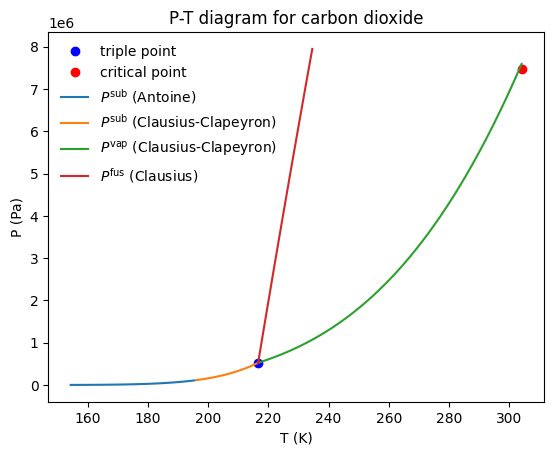

In [17]:
import matplotlib.pyplot as plt
import numpy as np

# Make a blank plot
fig, ax = plt.subplots()

# Plot the triple point
plt.plot(T_triple, P_triple, "bo", label="triple point")

# Plot the critical point
plt.plot(Tc, Pc, "ro", label="critical point")

# Plot the Antoine equation
T = np.arange(T_Antoine_min, T_Antoine_max, 1)
ax.plot(T, P_antoine(A, B, C, T), label=r"$P^\mathrm{sub}$ (Antoine)")

# Use Clausius-Clapeyron to plot the sublimation curve
T = np.linspace(T_Antoine_max, T_triple, 300)
P = P_CC(H_sub_1,T_triple, P_triple, T)
ax.plot(T, P, label=r"$P^\mathrm{sub}$ (Clausius-Clapeyron)")

# Use Clausius-Clapeyron to plot the vaporization curve
T = np.linspace(T_triple, Tc, 300)
P = P_CC(H_vap_1,T_triple, P_triple, T)
ax.plot(T, P, label=r"$P^\mathrm{vap}$ (Clausius-Clapeyron)")

# Use the integrated Clapeyron equation to plot the melting line
T = np.linspace(T_triple, T_triple+18, 100)
P = P_clapeyron(T_triple, P_triple, T, delta_fus_H, delta_fus_V)
ax.plot(T, P, label=r"$P^\mathrm{fus}$ (Clausius)")

# Label and axes
#plt.ylim([0,1e6])
#ax.set_yscale("log")
ax.legend(frameon=True, fancybox=True, edgecolor='none')
plt.xlabel('T (K)')
plt.ylabel('P (Pa)')
plt.title('P-T diagram for carbon dioxide')

This seems reasonable. You can see that the vaporization curve calculated by the Clausius-Clapeyron equation is senstive to the heat of vaporization. The value we use overestimates the critical point slightly. A slightly lower value would bring the two into agreement.

Let's rebuild the plot, but focus on the lower part of the phase diagram by plotting it on a log-linear scale.

Text(0.5, 1.0, 'P-T diagram for carbon dioxide')

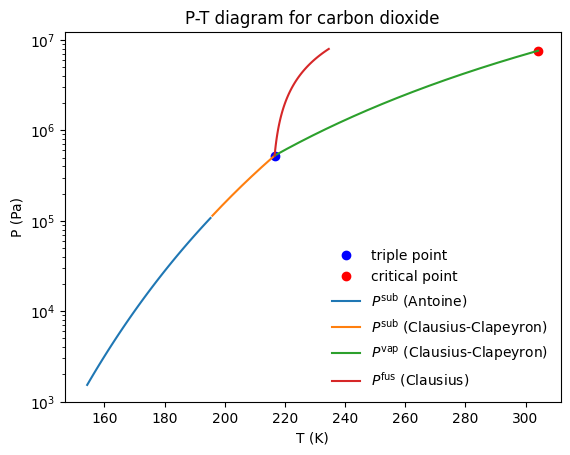

In [18]:
import matplotlib.pyplot as plt
import numpy as np

# Make a blank plot
fig, ax = plt.subplots()

# Plot the triple point
plt.plot(T_triple, P_triple, "bo", label="triple point")

# Plot the critical point
plt.plot(Tc, Pc, "ro", label="critical point")

# Plot the Antoine equation
T = np.arange(T_Antoine_min, T_Antoine_max, 1)
ax.plot(T, P_antoine(A, B, C, T), label=r"$P^\mathrm{sub}$ (Antoine)")

# Use Clausius-Clapeyron to plot the sublimation curve
T = np.linspace(T_Antoine_max, T_triple, 300)
P = P_CC(H_sub_1,T_triple, P_triple, T)
ax.plot(T, P, label=r"$P^\mathrm{sub}$ (Clausius-Clapeyron)")

# Use Clausius-Clapeyron to plot the vaporization curve
T = np.linspace(T_triple, Tc, 300)
P = P_CC(H_vap_1,T_triple, P_triple, T)
ax.plot(T, P, label=r"$P^\mathrm{vap}$ (Clausius-Clapeyron)")

# Use the integrated Clapeyron equation to plot the melting line
T = np.linspace(T_triple, T_triple+18, 100)
P = P_clapeyron(T_triple, P_triple, T, delta_fus_H, delta_fus_V)
ax.plot(T, P, label=r"$P^\mathrm{fus}$ (Clausius)")

# Label and axes
ax.set_yscale("log")
#plt.ylim([0,4e6])
#plt.xlim([T_Antoine_min,240])
ax.legend(frameon=True, fancybox=True, edgecolor='none')
plt.xlabel('T (K)')
plt.ylabel('P (Pa)')
plt.title('P-T diagram for carbon dioxide')

## Answer for part C of homework problem

In our exerpience with carbon dioxide, it is often in its gaseous state and sometimes in its solid form. The reason is clear: at atmospheric pressure, we are well below the triple point, the lowest temperature where we would observe a liquid carbon dioxide phase. 

When the gas phase is cooled (for instance, by a Joule-Thompson expansion) we expect to form the solid phase. Likewise, when handling dry ice, we observe that it sublimates directly to the gas phase without melting into a liquid first.

## Answer for part B

Part B asks us what the state of a full gas cylinder for a home carbonation system is at room temperature (298 K) given that the cylinder volume is 0.64 L and initially contains 410 g of
carbon dioxide.

In this case, we have the temperature and molar volume:

In [19]:
T = 298
V_molar = 0.64/1000/(410/MW)

print(f"Molar volume: {V_molar:.2e} m^3/mol")

Molar volume: 6.87e-05 m^3/mol


From the temperature, we know that we are below the critical temperature, and the molar volume is much less than critical volume. It's reasonable to assume that the carbon dioxide is in a liquid phase at this temperature and molar volume. Looking at the PV diagram we calculated in problem 1, this is close to the saturated liquid. 

The maximum pressure on the cylinder is 250 bar, which is 25 MPa, but this is likely the limit of the cylinder pressure limit. The CO2 would be supercritical in this case.

We can calculate the pressure using the Peng-Robinson equation of state.

In [20]:
"""
Generalized Peng-Robinson EOS 
PR_pressure returns the pressure given V, T, Pc, Tc, omega
PR_volume returns all molar volumes (real roots of EOS) given P, T, Pc, Tc, omega
"""
import numpy as np
from scipy import constants
from numpy.polynomial import Polynomial

R = constants.R # Set the gas constant to R

def calc_b(Pc,Tc):
    return 0.07780*R*Tc/Pc

def calc_a(T,Pc,Tc,omega):
    kappa = 0.37464 + 1.54226*omega - 0.26992*omega**2
    sqrtalpha = 1 + kappa*(1-np.sqrt(T/Tc))
    return 0.45724*R**2*Tc**2/Pc*sqrtalpha**2

# Calculate the presure given V, T for PR EOS
def PR_pressure(V,T,Pc,Tc,omega):
    a = calc_a(T,Pc,Tc,omega)
    b = calc_b(Pc,Tc)

    P = R*T/(V-b) - a/(V*(V+b)+b*(V-b))
    return P

# Calculate the molar volume given P, T for PR EOS in m^3/mol
# Note that we can return multiple real roots (up to three)
# The largest and smallest will be the vapor and liquid, respectively
def PR_volume(P, T, Pc, Tc, omega):
    # Calculate a, b, A, and B
    a = calc_a(T, Pc, Tc, omega)
    b = calc_b(Pc, Tc)
    A = a*P/R**2/T**2
    B = b*P/R/T

    # Definitions of alpha, beta, gamma in SIS Table 6.4-3 for PR EOS
    alpha = -1 + B
    beta = A - 3*B**2 -2*B
    gamma = -A*B + B**2 + B**3

    # polynomial with coefficients in increasing order: c0 + c1 x + c2 x**2 + ...
    p = Polynomial([ gamma, beta, alpha, 1 ])  

    roots = p.roots()        # returns all (possibly complex) roots of Z
    real_roots = roots.real[abs(roots.imag) < 1e-12]  # filter real ones

    # Convert real values of Z to molar volume
    V = real_roots*R*T/P

    return V



In [21]:
print(f"The pressure is: {PR_pressure(V_molar,298,Pc,Tc,omega):.2e} Pa")

The pressure is: 6.54e+06 Pa


The calculated pressure is very close to the vaporization curve.

The pressure from the Clausius-Clapeyron equation at this temperature is a little higher:

In [22]:
print(f"P^vap(298K) = {P_CC(H_vap_1,T_triple, P_triple, 298):.2e} Pa")

P^vap(298K) = 6.62e+06 Pa


But we noted that the Clausius-Clapeyron equation might overestimate the vapor pressure curve. A more accurate calculation is necessary.